In [1]:
import os
import sys
import pandas as pd
import numpy as np
import glob
import time
import gget
import scipy
from scipy.sparse import csr_matrix
import anndata as an
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import random
from importlib import reload
import warnings
import ot
from scipy.spatial.distance import pdist, squareform
from matplotlib.colors import ListedColormap
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import MinMaxScaler

"""WARNING: no warnings"""
warnings.filterwarnings("ignore")

source_path = os.path.abspath("../utilities/calculations/")
sys.path.append(source_path)
import centrality as central

## Load Population Data

In [2]:
%%time 
# 1MB resolution
resolution = 1000000

fpath = f"/nfs/turbo/umms-indikar/shared/projects/poreC/pipeline_outputs/higher_order/anndata/population_mESC_{resolution}_features.h5ad"

adata = sc.read_h5ad(fpath)

sc.logging.print_memory_usage()

adata

Memory usage: current 2.84 GB, difference +2.84 GB
CPU times: user 12 s, sys: 2.84 s, total: 14.8 s
Wall time: 17.7 s


AnnData object with n_obs × n_vars = 2579 × 2756467
    obs: 'bin_index', 'bin_start', 'bin_end', 'bin', 'chrom', 'chrom_bin', 'degree', 'genes', 'n_genes', 'ATACSeq_1', 'ATACSeq_2', 'ATACSeq_3', 'CTCF', 'H3K27ac', 'H3K27me3', 'RNA_1', 'RNA_2', 'RNA_3', 'RNA_4', 'RNA_5', 'RNA_6', 'PolII'
    var: 'read_index', 'basename', 'mean_mapq', 'median_mapq', 'n_chromosomes', 'order', 'n_bins', 'read_length_bp', 'genes', 'n_genes'
    uns: 'base_resolution', 'chrom_sizes', 'gdf', 'gene_map', 'intervals'
    layers: 'H'

In [4]:
adata.obs["bin_index"]

bin_name
chr9:121        0
chr19:26        1
chr4:127        2
chr8:21         3
chr10:57        4
             ... 
chr16:7      2574
chr1:159     2575
chr9:116     2576
chr14:125    2577
chr1:195     2578
Name: bin_index, Length: 2579, dtype: int64

In [5]:
# filter
H = adata.X.tocsr().astype(float)
print(f"raw shape = {H.shape}")

raw shape = (2579, 2756467)


In [6]:
# IQR filter on locus degree (rows)
s = np.asarray(H.sum(axis=1)).ravel()
q1, q3 = np.quantile(s, [0.25, 0.75])
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
row_mask = (s >= low) & (s <= high)

H = H[row_mask, :]
obs_idx = np.where(row_mask)[0]          # maps H rows -> adata.obs rows

In [7]:
# drop singletons (reads with < 2 loci after row filter)
col_sums = np.asarray(H.sum(axis=0)).ravel()
col_mask = col_sums >= 2
H = H[:, col_mask]
var_idx = np.where(col_mask)[0]          # maps H cols -> adata.var cols

In [8]:
# drop large hyperedges (reads with > 10 loci)
col_sums = np.asarray(H.sum(axis=0)).ravel()
col_mask = col_sums <= 10
H = H[:, col_mask]
var_idx = var_idx[col_mask]

print(f"filtered shape = {H.shape}")

filtered shape = (2335, 2039865)


In [ ]:
# node_scores, edge_scores = central.hevc(
#     H,
#     function='log-exp',   # 'linear', 'log-exp', or 'max'
#     maxiter=1000,
#     tol=1e-6,
#     verbose=True
# )

In [9]:
# centrality
node_scores, edge_scores = central.hevc(
    H,
    function='max',   # 'linear', 'log-exp', or 'max'
    maxiter=1000,
    tol=1e-6,
    verbose=True
)

1 ...
2 ...
3 ...
4 ...
5 ...
6 ...
7 ...
8 ...
9 ...
23 ===


In [10]:
adata.obs["chrom_bin"].values

array([121,  26, 127, ..., 116, 125, 195], shape=(2579,))

In [11]:
node_df = pd.DataFrame({
    "chrom_bin":    adata.obs["chrom_bin"].iloc[obs_idx].values,
    "chrom":        adata.obs["chrom"].iloc[obs_idx].values,
    "bin_start":    adata.obs["bin_start"].iloc[obs_idx].values,
    "bin_end":      adata.obs["bin_end"].iloc[obs_idx].values,
    "node_score":   node_scores,
})

edge_df = pd.DataFrame({
    "read_index":   adata.var["read_index"].iloc[var_idx].values,
    "n_bins":       adata.var["n_bins"].iloc[var_idx].values,
    "edge_score":   edge_scores,
})

print(node_df.head())
print(edge_df.head())

   chrom_bin chrom  bin_start    bin_end  node_score
0        121     9  121000000  122000000    0.000431
1         26    19   26000000   27000000    0.000425
2        127     4  127000000  128000000    0.000437
3         57    10   57000000   58000000    0.000423
4          8    12    8000000    9000000    0.000431
   read_index  n_bins    edge_score
0           0       2  4.788751e-07
1           1      12  5.273094e-07
2           2       7  5.203198e-07
3           5       2  4.789579e-07
4           6       2  4.667536e-07


In [12]:
print("=== Node scores ===")
print(node_df["node_score"].describe())
print(f"  zeros:     {(node_df['node_score'] == 0).sum()}")
print(f"  neg:       {(node_df['node_score'] < 0).sum()}")

print("\n=== Edge scores ===")
print(edge_df["edge_score"].describe())
print(f"  zeros:     {(edge_df['edge_score'] == 0).sum()}")
print(f"  neg:       {(edge_df['edge_score'] < 0).sum()}")

=== Node scores ===
count    2335.000000
mean        0.000428
std         0.000009
min         0.000396
25%         0.000423
50%         0.000429
75%         0.000434
max         0.000455
Name: node_score, dtype: float64
  zeros:     0
  neg:       0

=== Edge scores ===
count    2.039865e+06
mean     4.902285e-07
std      1.592879e-08
min      4.415305e-07
25%      4.777787e-07
50%      4.889913e-07
75%      5.012942e-07
max      5.468857e-07
Name: edge_score, dtype: float64
  zeros:     0
  neg:       0


In [13]:
spath = "/nfs/turbo/umms-indikar/shared/projects/poreC/pipeline_outputs/higher_order/global_core_score/population_mESC_1000000_scores.csv"

score = pd.read_csv(spath)
score.columns

Index(['bin_name', 'bin_index', 'bin_start', 'bin_end', 'bin', 'chrom',
       'chrom_bin', 'degree', 'genes', 'n_genes', 'ATACSeq_1', 'ATACSeq_2',
       'ATACSeq_3', 'CTCF', 'H3K27ac', 'H3K27me3', 'RNA_1', 'RNA_2', 'RNA_3',
       'RNA_4', 'RNA_5', 'RNA_6', 'degree_outlier', 'chrom_degree',
       'ce_singular_vector_1', 'ce_eigenvector_centrality',
       'ce_betweenness_centrality', 'ce_pagerank', 'hge_singular_vector_1',
       'hge_logexp_unweighted', 'hge_logexp_degree_weighted',
       'hge_logexp_RNA_weighted', 'hge_logexp_ATAC_weighted',
       'global_singular_vector_1', 'global_hge_logexp_unweighted',
       'global_hge_logexp_RNA_weighted'],
      dtype='object')

In [14]:
node_df = pd.DataFrame({
    "bin_name":                    ("chr" + adata.obs["chrom"].iloc[obs_idx].astype(str) + ":" +
                                     adata.obs["chrom_bin"].iloc[obs_idx].astype(str)).values,
    "chrom":                        adata.obs["chrom"].iloc[obs_idx].values,
    "bin_start":                    adata.obs["bin_start"].iloc[obs_idx].values,
    "bin_end":                      adata.obs["bin_end"].iloc[obs_idx].values,
    "global_hge_max_unweighted": node_scores,
})

In [15]:
node_df.head()

,bin_name,chrom,bin_start,bin_end,global_hge_max_unweighted
0,chr9:121,9,121000000,122000000,0.000431
1,chr19:26,19,26000000,27000000,0.000425
2,chr4:127,4,127000000,128000000,0.000437
3,chr10:57,10,57000000,58000000,0.000423
4,chr12:8,12,8000000,9000000,0.000431


In [16]:
node_df.to_csv("/nfs/turbo/umms-indikar/shared/projects/poreC/pipeline_outputs/higher_order/global_core_score/pop_mESC_1000000_hge_max.csv", index=False)

In [17]:
node_df.describe()

,bin_start,bin_end,global_hge_max_unweighted
count,2.335000e+03,2.335000e+03,2335.000000
mean,6.977088e+07,7.077088e+07,0.000428
std,4.262436e+07,4.262436e+07,0.000009
min,3.000000e+06,4.000000e+06,0.000396
25%,3.400000e+07,3.500000e+07,0.000423
50%,6.600000e+07,6.700000e+07,0.000429
75%,1.005000e+08,1.015000e+08,0.000434
max,1.940000e+08,1.950000e+08,0.000455


In [19]:
threshold = node_df['global_hge_max_unweighted'].quantile(0.90)
top_10_percent_df = node_df[node_df['global_hge_max_unweighted'] >= threshold]

In [20]:
top_10_percent_df.describe()

,bin_start,bin_end,global_hge_max_unweighted
count,2.340000e+02,2.340000e+02,234.000000
mean,7.550000e+07,7.650000e+07,0.000443
std,4.281403e+07,4.281403e+07,0.000003
min,3.000000e+06,4.000000e+06,0.000439
25%,3.800000e+07,3.900000e+07,0.000440
50%,7.850000e+07,7.950000e+07,0.000443
75%,1.130000e+08,1.140000e+08,0.000446
max,1.740000e+08,1.750000e+08,0.000455


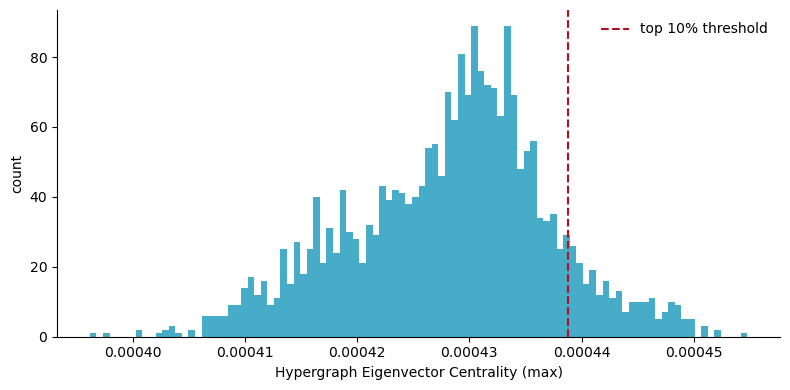

In [23]:
import matplotlib.pyplot as plt

p25 = node_df["global_hge_max_unweighted"].quantile(0.90)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(node_df["global_hge_max_unweighted"], bins=100, color="#46ACC8", edgecolor="none")
ax.axvline(p25, color="#B40F20", linestyle="--", label=f"top 10% threshold")
ax.set_xlabel("Hypergraph Eigenvector Centrality (max)")
ax.set_ylabel("count")
#ax.set_title("Distribution of Node Centrality Scores")
ax.legend(frameon=False)
sns.despine(top=True)
plt.tight_layout()
plt.show()